# 03 - Evaluasi ROUGE & Perbandingan Waktu Proses Transkrip (MP4 vs MP3 vs WAV)

Mengevaluasi performa model IndoT5 dan membandingkan waktu transkripsi Whisper antar format file.

## 1. Import

In [1]:
import pandas as pd
import evaluate
import time
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch
import matplotlib.pyplot as plt

# untuk baca file penegtesan waktu transkrip
import os
ffmpeg_dir = r"C:\Users\User\AppData\Local\Microsoft\WinGet\Packages"
for root, dirs, files in os.walk(ffmpeg_dir):
    if "ffmpeg.exe" in files:
        os.environ["PATH"] = root + ";" + os.environ["PATH"]
        print(f"FFmpeg ditemukan: {root}")
        break


d:\Skripsi\meeting-summarizer\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


FFmpeg ditemukan: C:\Users\User\AppData\Local\Microsoft\WinGet\Packages\Gyan.FFmpeg_Microsoft.Winget.Source_8wekyb3d8bbwe\ffmpeg-8.0.1-full_build\bin


## 2. Load Model Fine-tuned

In [2]:
MODEL_DIR = Path('../models/indot5_finetuned')
print(f"Memuat tokenizer dan model dari: {MODEL_DIR}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model     = AutoModelForSeq2SeqLM.from_pretrained(MODEL_DIR)

device    = 'cuda' if torch.cuda.is_available() else 'cpu'
model     = model.to(device).eval()
print(f"Model berhasil dimuat di device: {device}")

df_test = pd.read_csv('../dataset/03_paired/test.csv')
df_test.head()

Memuat tokenizer dan model dari: ..\models\indot5_finetuned...


Loading weights: 100%|██████████| 284/284 [00:00<00:00, 805.61it/s, Materializing param=shared.weight]                                                       
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Model berhasil dimuat di device: cpu


,input_whisper_segment,target_summary_manual
0,hadirin kami persilakan untuk duduk kembali si...,Rapat Paripurna DPR RI membahas laporan Komisi...
1,"pertama-tama, marilah kita panjatkan pujisukur...",Komisi 3 DPR RI melaksanakan uji kelayakan ter...
2,pengambilan keputusan dilakukan dengan cara mu...,Komisi 3 DPR RI menyetujui 7 calon anggota LPS...
3,sebelum memasuki acara terakhir kami persilaka...,Rapat Paripurna DPR RI menutup masa persidanga...
4,dpr memberikan perhatian yang besar atas kondi...,DPR RI memperhatikan kondisi ekonomi rakyat da...


## 3. Fungsi Prediksi

In [3]:
PREFIX = 'ringkas: '

def predict(text: str, max_new_tokens: int = 128) -> str:
    inp = tokenizer(
        PREFIX + str(text),
        return_tensors='pt',
        max_length=512,
        truncation=True,
    ).to(device)

    with torch.no_grad():
        out = model.generate(
            **inp,
            max_new_tokens=max_new_tokens,
            num_beams=4,
            no_repeat_ngram_size=3,
            repetition_penalty=2.0,
            early_stopping=True,
        )
    return tokenizer.decode(out[0], skip_special_tokens=True)

## 4. Hitung Skor ROUGE

In [4]:
rouge = evaluate.load('rouge')

print("Sedang memproses prediksi ringkasan pada data Test...")
preds = [predict(s) for s in df_test['input_whisper_segment']]
refs  = df_test['target_summary_manual'].tolist()

results = rouge.compute(predictions=preds, references=refs)

print("\nEVALUASI ROUGE PADA DATA TEST")
print("=====================================")
for k, v in results.items():
    print(f'{k}: {v:.4f}')

Sedang memproses prediksi ringkasan pada data Test...

EVALUASI ROUGE PADA DATA TEST
rouge1: 0.3609
rouge2: 0.1511
rougeL: 0.2239
rougeLsum: 0.2244


## Pengecekan Hasil Ringkasan Model Finetuned

In [5]:
print("CEK RINGKASAN HASIL PREDIKSI DATA TEST (FINETUNING)")
print("=" * 80)

# ambil 5 baris pertama dari data test
for i in range(5):
    teks_input = df_test['input_whisper_segment'].iloc[i]
    target_manual = df_test['target_summary_manual'].iloc[i]
    
    # Panggil fungsi predict
    hasil_prediksi = predict(teks_input)
    
    print(f"\nSAMPEL {i+1}")
    print(f"TRANSKRIP CHUNK: {teks_input[:150]}...")
    print(f"TARGET MANUAL       : {target_manual}")
    print(f"HASIL INDOT5     : {hasil_prediksi}")
    print("-" * 80)

CEK RINGKASAN HASIL PREDIKSI DATA TEST (FINETUNING)

SAMPEL 1
TRANSKRIP CHUNK: hadirin kami persilakan untuk duduk kembali sidang dewan yang kami hormati sesuai dengan hasil keputusan rapat konsultasi pengganti rapat badan musyaw...
TARGET MANUAL       : Rapat Paripurna DPR RI membahas laporan Komisi III tentang hasil uji kelayakan calon anggota Lembaga Perlindungan Saksi dan Korban masa jabatan 2024-2029. Pimpinan Komisi III, Dr. Habibur Rahman, menyampaikan laporan. Rapat juga membahas pidato Ketua DPR RI pada penutupan Masa Persidangan IV Tahun Sidang 2023-2024.
HASIL INDOT5     : DPR RI menyampaikan laporan dari Komisi 3 Dewan atas hasil uji kelayakan untuk calon anggota lembaga perlindungan saksi dan korban tahun 2024-2025. Anggota Parlemen juga memberikan keputusan, yang akan dilakukan pada 25 Maret 1523-2026 (diapresiasi dengan kebijakan di dalam rapat ini. Pemerintah telah melakukan pembahasan tentang program kerja pemerintah serta proses pengambilan tindakan.
-----------------

## 5. Perbandingan Waktu Transkripsi per Format File

In [6]:
import sys
sys.path.append('..')
from modules.transcriber import transcribe_audio

FILES = {
    'MP4': Path('../dataset/01_raw/video_mp4/Paripurna_Ke_11_Persidangan_II_2024_2025.mp4'),
    'MP3': Path('../dataset/01_raw/audio_mp3/Paripurna_Ke_11_Persidangan_II_2024_2025.mp3'),
    'WAV': Path('../dataset/01_raw/audio_wav/Paripurna_Ke_11_Persidangan_II_2024_2025.wav'),
}

hasil_waktu = {}
print("Mulai uji coba waktu transkripsi Whisper...")

for label, fp in FILES.items():
    if not fp.exists():
        print(f'[SKIP] {fp} tidak ditemukan')
        continue
    t0 = time.time()
    transcribe_audio(fp)
    hasil_waktu[label] = round(time.time() - t0, 2)
    print(f'{label}: {hasil_waktu[label]} detik')

df_waktu = pd.DataFrame(list(hasil_waktu.items()), columns=['Format', 'Waktu (detik)'])
df_waktu

Mulai uji coba waktu transkripsi Whisper...


d:\Skripsi\meeting-summarizer\venv\Lib\site-packages\whisper\transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")
 95%|█████████▍| 54501/57501 [08:49<00:29, 102.98frames/s]


MP4: 548.05 detik


 95%|█████████▍| 54500/57500 [07:15<00:23, 125.26frames/s]


MP3: 436.19 detik


 95%|█████████▍| 54500/57500 [06:23<00:21, 142.17frames/s]

WAV: 383.74 detik


,Format,Waktu (detik)
0,MP4,548.05
1,MP3,436.19
2,WAV,383.74


## 6. Visualisasi Perbandingan Waktu

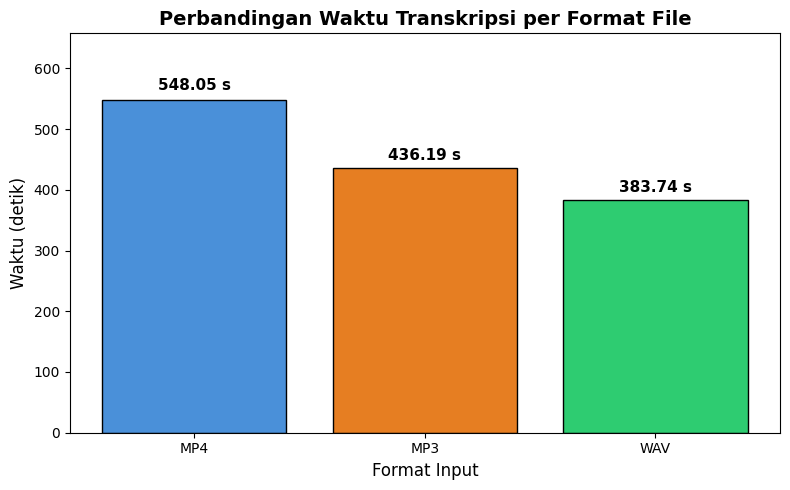

Grafik visualisasi waktu berhasil disimpan!


In [7]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    df_waktu['Format'],
    df_waktu['Waktu (detik)'],
    color=['#4A90D9', '#E67E22', '#2ECC71'],
    edgecolor='black' 
)

plt.title('Perbandingan Waktu Transkripsi per Format File', fontsize=14, fontweight='bold')
plt.ylabel('Waktu (detik)', fontsize=12)
plt.xlabel('Format Input', fontsize=12)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (yval * 0.02), f'{yval} s', 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.ylim(0, df_waktu['Waktu (detik)'].max() * 1.2)

plt.tight_layout()
plt.savefig('../dataset/perbandingan_waktu.png', dpi=150, bbox_inches='tight')
plt.show()

print("Grafik visualisasi waktu berhasil disimpan!")